# 物体检测和数据集

## 物体检测

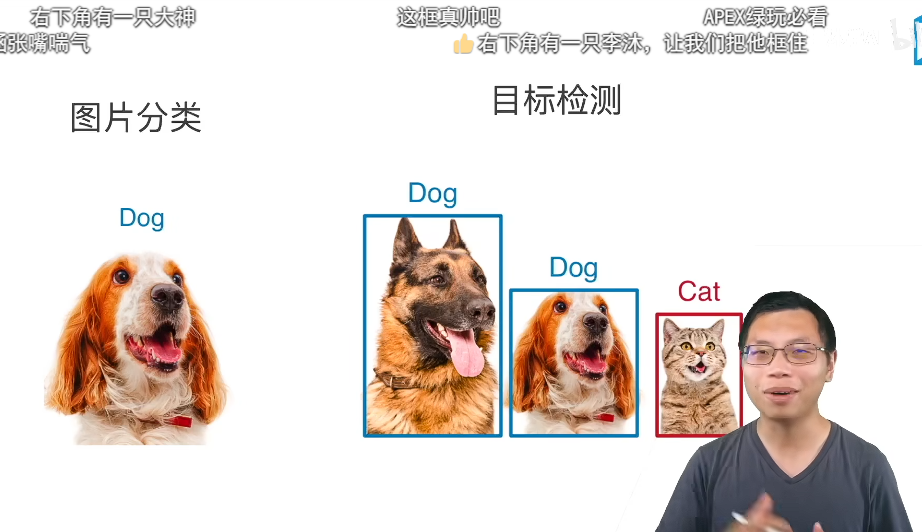

边缘框表示物体位置

1. 左上点 + 右下点
2. 左上点 + 宽 +高

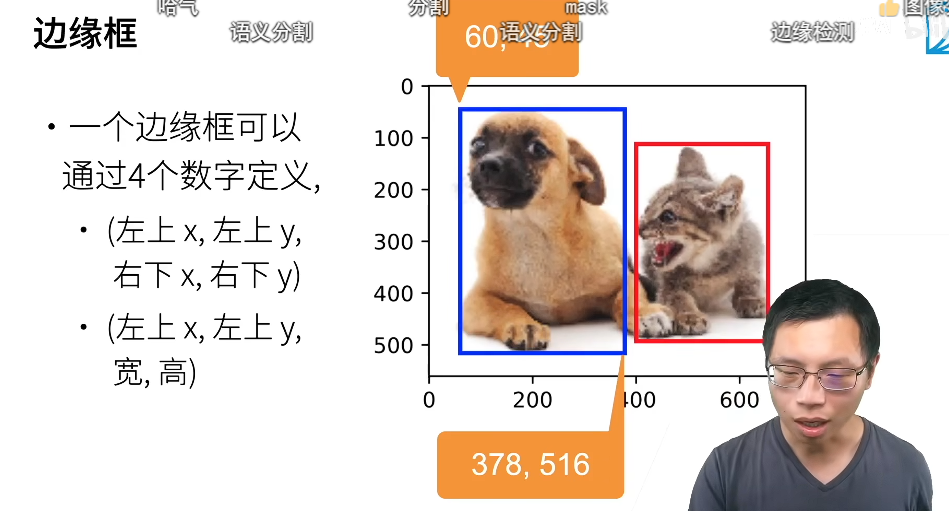

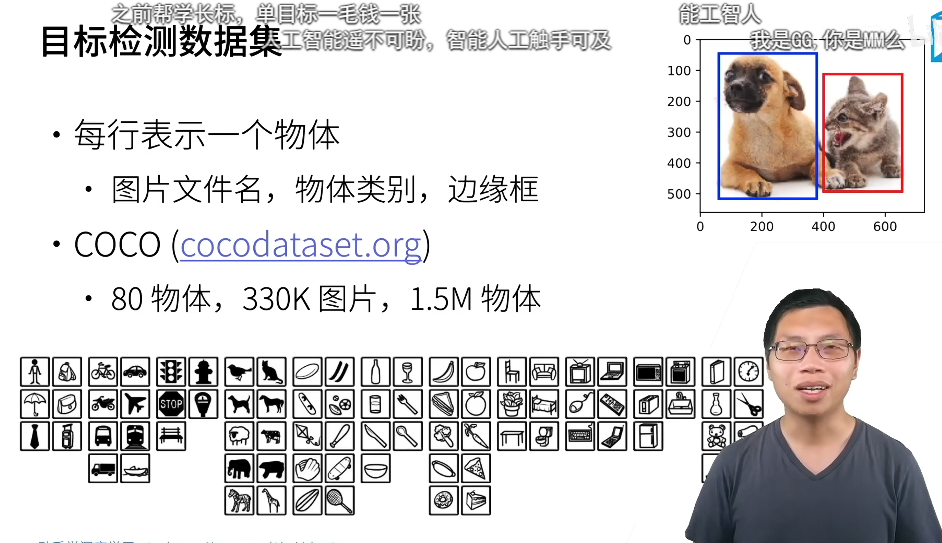

数据集：图片文件名，物体类别，边缘框

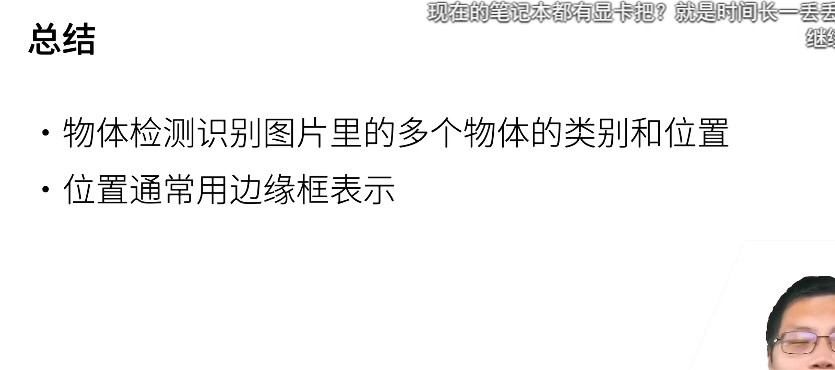

## 物体检测代码实现

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

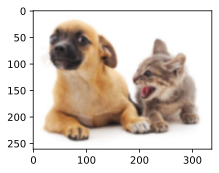

In [2]:
d2l.set_figsize()
img = d2l.plt.imread(r'D:\document\笔记\深度学习\李沐动手学深度学习\data\dogcat.png')
d2l.plt.imshow(img)

定义两种表示之间转换的函数

In [3]:
#@save
def box_corner_to_center(boxes):
    """从（左上，右下）转换到（中间，宽度，高度）"""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    boxes = torch.stack((cx, cy, w, h), axis=-1)
    return boxes

#@save
def box_center_to_corner(boxes):
    """从（中间，宽度，高度）转换到（左上，右下）"""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes

In [8]:
# bbox是边界框的英文缩写
dog_bbox, cat_bbox = [20.0, 10.0, 220.0, 250.0], [190.0, 50.0, 310.0, 240.0]
boxes = torch.tensor((dog_bbox, cat_bbox))
box_center_to_corner(box_corner_to_center(boxes)) == boxes

tensor([[True, True, True, True],
        [True, True, True, True]])

In [9]:
#@save
def bbox_to_rect(bbox, color):
    # 将边界框(左上x,左上y,右下x,右下y)格式转换成matplotlib格式：
    # ((左上x,左上y),宽,高)
    return d2l.plt.Rectangle(
        xy=(bbox[0], bbox[1]), width=bbox[2]-bbox[0], height=bbox[3]-bbox[1],
        fill=False, edgecolor=color, linewidth=2)

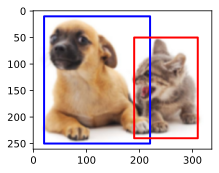

In [10]:
fig = d2l.plt.imshow(img)
fig.axes.add_patch(bbox_to_rect(dog_bbox, 'blue'))
fig.axes.add_patch(bbox_to_rect(cat_bbox, 'red'));

## 目标检测数据集

In [11]:
%matplotlib inline
import os
import pandas as pd
import torch
import torchvision
from d2l import torch as d2l

In [16]:
def read_data_bananas(is_train=True):
    """读取香蕉检测数据集中的图像和标签（直接使用本地路径）"""
    # ① 直接指定你的本地数据集根目录（确保路径正确）
    data_dir = r'D:\document\笔记\深度学习\李沐动手学深度学习\data\banana-detection'
    
    # ② 根据训练/验证选择子文件夹
    sub_dir = 'bananas_train' if is_train else 'bananas_val'
    
    # ③ 拼接 label.csv 的完整路径
    csv_fname = os.path.join(data_dir, sub_dir, 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        # ④ 拼接图像路径
        img_path = os.path.join(data_dir, sub_dir, 'images', f'{img_name}')
        images.append(torchvision.io.read_image(img_path))
        targets.append(list(target))
    
    # ⑤ 将坐标除以256（因为图像尺寸是256x256，归一化到0~1之间）
    return images, torch.tensor(targets).unsqueeze(1) / 256

In [17]:
#@save
class BananasDataset(torch.utils.data.Dataset):
    """一个用于加载香蕉检测数据集的自定义数据集"""
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

In [18]:
#@save
def load_data_bananas(batch_size):
    """加载香蕉检测数据集"""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

In [19]:
batch_size, edge_size = 32, 256
train_iter, _ = load_data_bananas(batch_size)
batch = next(iter(train_iter))
batch[0].shape, batch[1].shape

read 1000 training examples
read 100 validation examples


(torch.Size([32, 3, 256, 256]), torch.Size([32, 1, 5]))

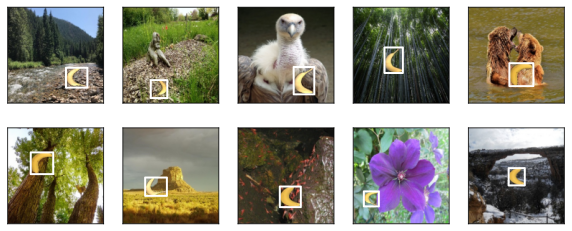

In [20]:
imgs = (batch[0][0:10].permute(0, 2, 3, 1)) / 255
axes = d2l.show_images(imgs, 2, 5, scale=2)
for ax, label in zip(axes, batch[1][0:10]):
    d2l.show_bboxes(ax, [label[0][1:5] * edge_size], colors=['w'])